In [4]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon
import cv2
import random
import matplotlib.image as mpimg
import warnings
warnings.filterwarnings('ignore')

In [2]:
BASE_PATH = "../BoneFractureYolo8"

train_images = os.path.join(BASE_PATH, "train", "images")
train_labels = os.path.join(BASE_PATH, "train", "labels")

val_images = os.path.join(BASE_PATH, "valid", "images")
val_labels = os.path.join(BASE_PATH, "valid", "labels")

test_images = os.path.join(BASE_PATH, "test", "images")
test_labels = os.path.join(BASE_PATH, "test", "labels")

In [3]:
print('Number of train frames: ' + str(len(os.listdir(train_images))))
print('Number of train labels: ' + str(len(os.listdir(train_labels))))
print('Number of val frames: ' + str(len(os.listdir(val_images))))
print('Number of val labels: ' + str(len(os.listdir(val_labels))))
print('Number of test frames: ' + str(len(os.listdir(test_images))))
print('Number of test labels: ' + str(len(os.listdir(test_labels))))
print('Total frames: ' + str(len(os.listdir(train_images)) + len(os.listdir(test_images)) + len(os.listdir(val_images))))

Number of train frames: 3631
Number of train labels: 3631
Number of val frames: 348
Number of val labels: 348
Number of test frames: 169
Number of test labels: 169
Total frames: 4148


In [8]:
CLASS_NAMES = [
    'elbow positive', 'fingers positive', 'forearm fracture',
    'humerus fracture', 'humerus', 'shoulder fracture', 'wrist positive'
]

# Using one distinct RGB colour per class (values 0-1)
CLASS_COLORS = [
    (1.00, 0.39, 0.28),   # 0  elbow positive      
    (1.00, 0.65, 0.00),   # 1  fingers positive    
    (0.20, 0.80, 0.20),   # 2  forearm fracture   
    (0.12, 0.56, 1.00),   # 3  humerus fracture   
    (0.58, 0.00, 0.83),   # 4  humerus            
    (1.00, 0.08, 0.58),   # 5  shoulder fracture   
    (0.00, 0.81, 0.82),   # 6  wrist positive      
]

In [6]:
import os
import shutil

# config
SPLITS = [
    ("train", train_labels),
    ("valid", val_labels),
    ("test",  test_labels),
]

# old class ids
OLD_HUMERUS_FRACTURE = CLASS_NAMES.index("humerus fracture")  # 3
OLD_HUMERUS          = CLASS_NAMES.index("humerus")           # 4
REMOVE_CLASS_ID      = OLD_HUMERUS_FRACTURE                   # we remove class 3

def remap_class_id(old_id: int) -> int:
    # Merge 'humerus fracture' into 'humerus', then remove old class 3.
    # After removal, all class ids > 3 shift down by 1.
    
    # merge 3 -> 4
    if old_id == OLD_HUMERUS_FRACTURE:
        old_id = OLD_HUMERUS

    # remove class 3 -> shift down ids > 3
    if old_id > REMOVE_CLASS_ID:
        return old_id - 1
    else:
        return old_id

def backup_and_rewrite_labels(labels_dir: str):
    # backup once
    backup_dir = labels_dir.rstrip("/\\") + "_backup_before_merge"
    if not os.path.exists(backup_dir):
        shutil.copytree(labels_dir, backup_dir)
        print(f"Backup created: {backup_dir}")
    else:
        print(f"Backup already exists: {backup_dir} (skipping copy)")

    changed = 0
    total_files = 0

    for fname in os.listdir(labels_dir):
        if not fname.endswith(".txt"):
            continue
        total_files += 1
        path = os.path.join(labels_dir, fname)

        # keep empty files as-is
        if os.path.getsize(path) == 0:
            continue

        new_lines = []
        modified = False

        with open(path, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                old_cls = int(float(parts[0]))
                new_cls = remap_class_id(old_cls)
                if new_cls != old_cls:
                    modified = True
                parts[0] = str(new_cls)
                new_lines.append(" ".join(parts))

        if modified:
            changed += 1

        # rewrite only if modified to avoid unnecessary file writes
        if modified:
            with open(path, "w") as f:
                f.write("\n".join(new_lines) + ("\n" if new_lines else ""))

    print(f"Rewrote {changed} label files (out of {total_files}) in: {labels_dir}")

# apply to all splits
for split_name, lbl_dir in SPLITS:
    print(f"\n--- Updating {split_name} labels ---")
    backup_and_rewrite_labels(lbl_dir)


--- Updating train labels ---
Backup created: ../BoneFractureYolo8\train\labels_backup_before_merge
Rewrote 782 label files (out of 3631) in: ../BoneFractureYolo8\train\labels

--- Updating valid labels ---
Backup created: ../BoneFractureYolo8\valid\labels_backup_before_merge
Rewrote 67 label files (out of 348) in: ../BoneFractureYolo8\valid\labels

--- Updating test labels ---
Backup created: ../BoneFractureYolo8\test\labels_backup_before_merge
Rewrote 35 label files (out of 169) in: ../BoneFractureYolo8\test\labels


Update classes 

In [9]:
# Remove "humerus fracture" from CLASS_NAMES / CLASS_COLORS
remove_idx = CLASS_NAMES.index("humerus fracture")

CLASS_NAMES_MERGED  = [c for i, c in enumerate(CLASS_NAMES)  if i != remove_idx]
CLASS_COLORS_MERGED = [c for i, c in enumerate(CLASS_COLORS) if i != remove_idx]

print("New classes:")
for i, name in enumerate(CLASS_NAMES_MERGED):
    print(i, name)

New classes:
0 elbow positive
1 fingers positive
2 forearm fracture
3 humerus
4 shoulder fracture
5 wrist positive



TRAIN label files: 3631 | empty (no boxes): 1827
  elbow positive: 339
  fingers positive: 531
  forearm fracture: 316
  humerus: 314
  shoulder fracture: 360
  wrist positive: 228


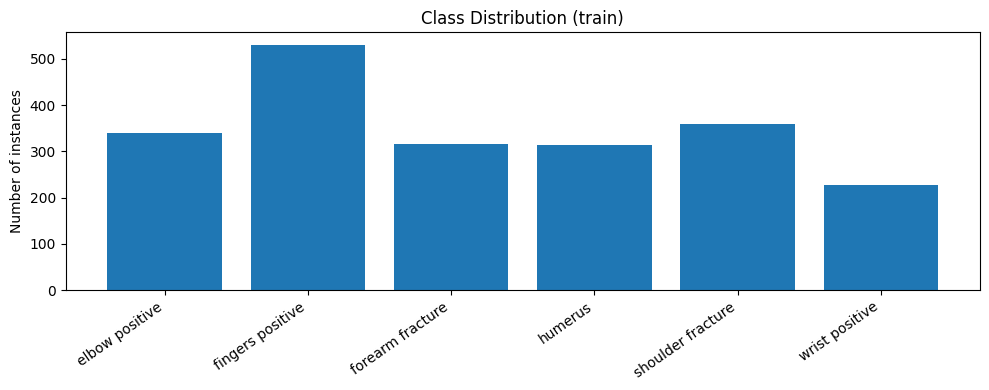


VALID label files: 348 | empty (no boxes): 175
  elbow positive: 29
  fingers positive: 48
  forearm fracture: 43
  humerus: 36
  shoulder fracture: 20
  wrist positive: 28


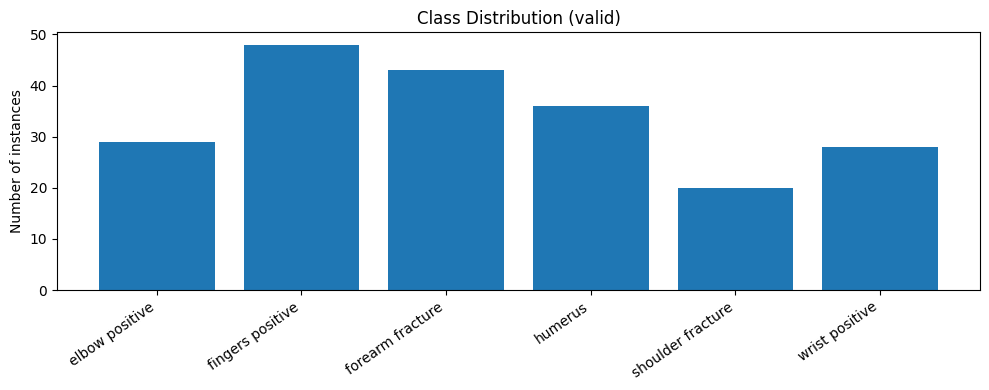


TEST label files: 169 | empty (no boxes): 86
  elbow positive: 17
  fingers positive: 27
  forearm fracture: 14
  humerus: 15
  shoulder fracture: 17
  wrist positive: 6


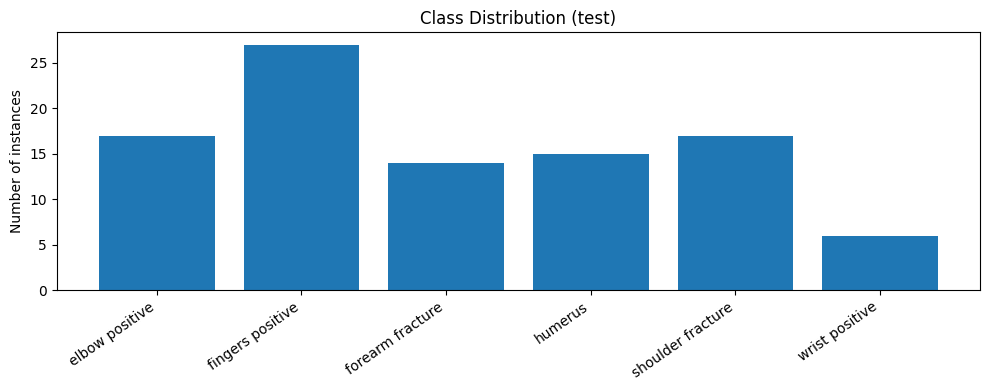

In [10]:
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

def count_classes(labels_dir: str):
    counts = Counter()
    empty = 0
    total = 0

    for fname in os.listdir(labels_dir):
        if not fname.endswith(".txt"):
            continue
        total += 1
        path = os.path.join(labels_dir, fname)

        if os.path.getsize(path) == 0:
            empty += 1
            continue

        with open(path, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                cls = int(float(parts[0]))
                counts[cls] += 1

    return counts, empty, total

def plot_class_dist(counts, title):
    xs = list(range(len(CLASS_NAMES_MERGED)))
    ys = [counts.get(i, 0) for i in xs]

    plt.figure(figsize=(10,4))
    plt.bar(xs, ys)
    plt.xticks(xs, CLASS_NAMES_MERGED, rotation=35, ha="right")
    plt.ylabel("Number of instances")
    plt.title(title)
    plt.tight_layout()
    plt.show()

for split_name, lbl_dir in SPLITS:
    counts, empty, total = count_classes(lbl_dir)
    print(f"\n{split_name.upper()} label files: {total} | empty (no boxes): {empty}")
    for i, name in enumerate(CLASS_NAMES_MERGED):
        print(f"  {name}: {counts.get(i,0)}")
    plot_class_dist(counts, f"Class Distribution ({split_name})")

#### Analyze bounding box sizes

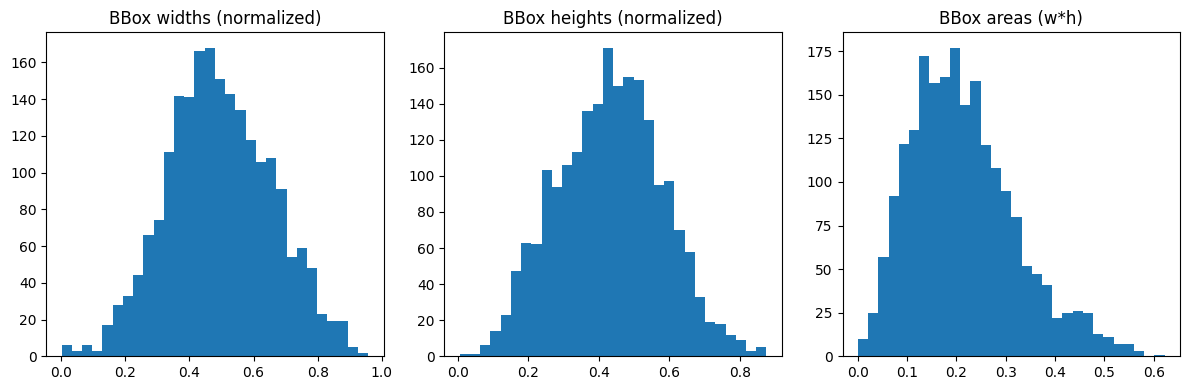

BBox width percentiles: [0.23044018 0.38163225 0.48696306 0.61045563 0.77312427]
BBox height percentiles: [0.18292264 0.32495799 0.43563065 0.53235432 0.66774384]
BBox area percentiles: [0.06500115 0.13560408 0.20059473 0.27871592 0.42581502]


In [12]:
def collect_bbox_stats(labels_dir: str):
    ws, hs, areas = [], [], []
    for fname in os.listdir(labels_dir):
        if not fname.endswith(".txt"):
            continue
        path = os.path.join(labels_dir, fname)
        if os.path.getsize(path) == 0:
            continue

        with open(path, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                w = float(parts[3]) 
                h = float(parts[4])
                ws.append(w)
                hs.append(h)
                areas.append(w*h)
    return np.array(ws), np.array(hs), np.array(areas)

ws, hs, areas = collect_bbox_stats(train_labels)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.hist(ws, bins=30); plt.title("BBox widths (normalized)")
plt.subplot(1,3,2); plt.hist(hs, bins=30); plt.title("BBox heights (normalized)")
plt.subplot(1,3,3); plt.hist(areas, bins=30); plt.title("BBox areas (w*h)")
plt.tight_layout()
plt.show()

print("BBox width percentiles:", np.percentile(ws, [5,25,50,75,95]))
print("BBox height percentiles:", np.percentile(hs, [5,25,50,75,95]))
print("BBox area percentiles:", np.percentile(areas, [5,25,50,75,95]))

This shows that there aren't many extremely small boxes, which is good since it makes fractures easier to detect. Detection should be relatively stable.

#### Fracture location heatmap across image

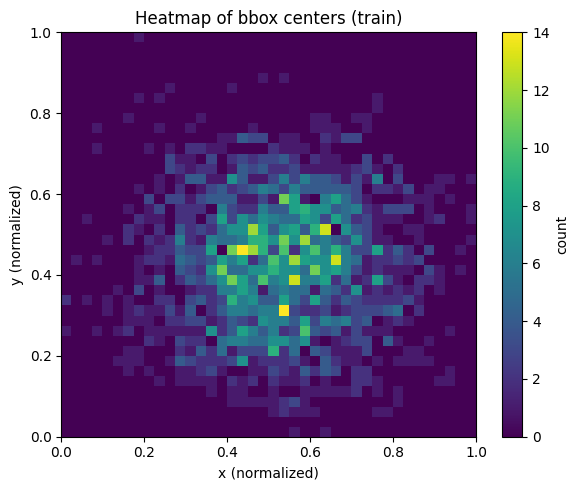

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def fracture_center_heatmap(images_dir: str, labels_dir: str, bins=40, n_samples=None, seed=42):
    img_files = [f for f in os.listdir(images_dir) if f.lower().endswith((".jpg",".jpeg",".png"))]
    if n_samples is not None:
        random.seed(seed)
        img_files = random.sample(img_files, k=min(n_samples, len(img_files)))

    xs, ys = [], []

    for img_name in img_files:
        label_name = os.path.splitext(img_name)[0] + ".txt"
        label_path = os.path.join(labels_dir, label_name)
        if not os.path.exists(label_path) or os.path.getsize(label_path) == 0:
            continue

        with open(label_path, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                xc = float(parts[1])
                yc = float(parts[2])
                xs.append(xc)
                ys.append(yc)

    xs = np.array(xs); ys = np.array(ys)
    H, xedges, yedges = np.histogram2d(ys, xs, bins=bins, range=[[0,1],[0,1]])

    plt.figure(figsize=(6,5))
    plt.imshow(H, origin="lower", extent=[0,1,0,1], aspect="auto")
    plt.colorbar(label="count")
    plt.title("Heatmap of bbox centers (train)")
    plt.xlabel("x (normalized)")
    plt.ylabel("y (normalized)")
    plt.tight_layout()
    plt.show()

fracture_center_heatmap(train_images, train_labels, bins=40)

We can see that most centers of the box are centered on the bone. However, it also implies that the dataset has spatial bias. The models might learn that fractures usually appear in the center.

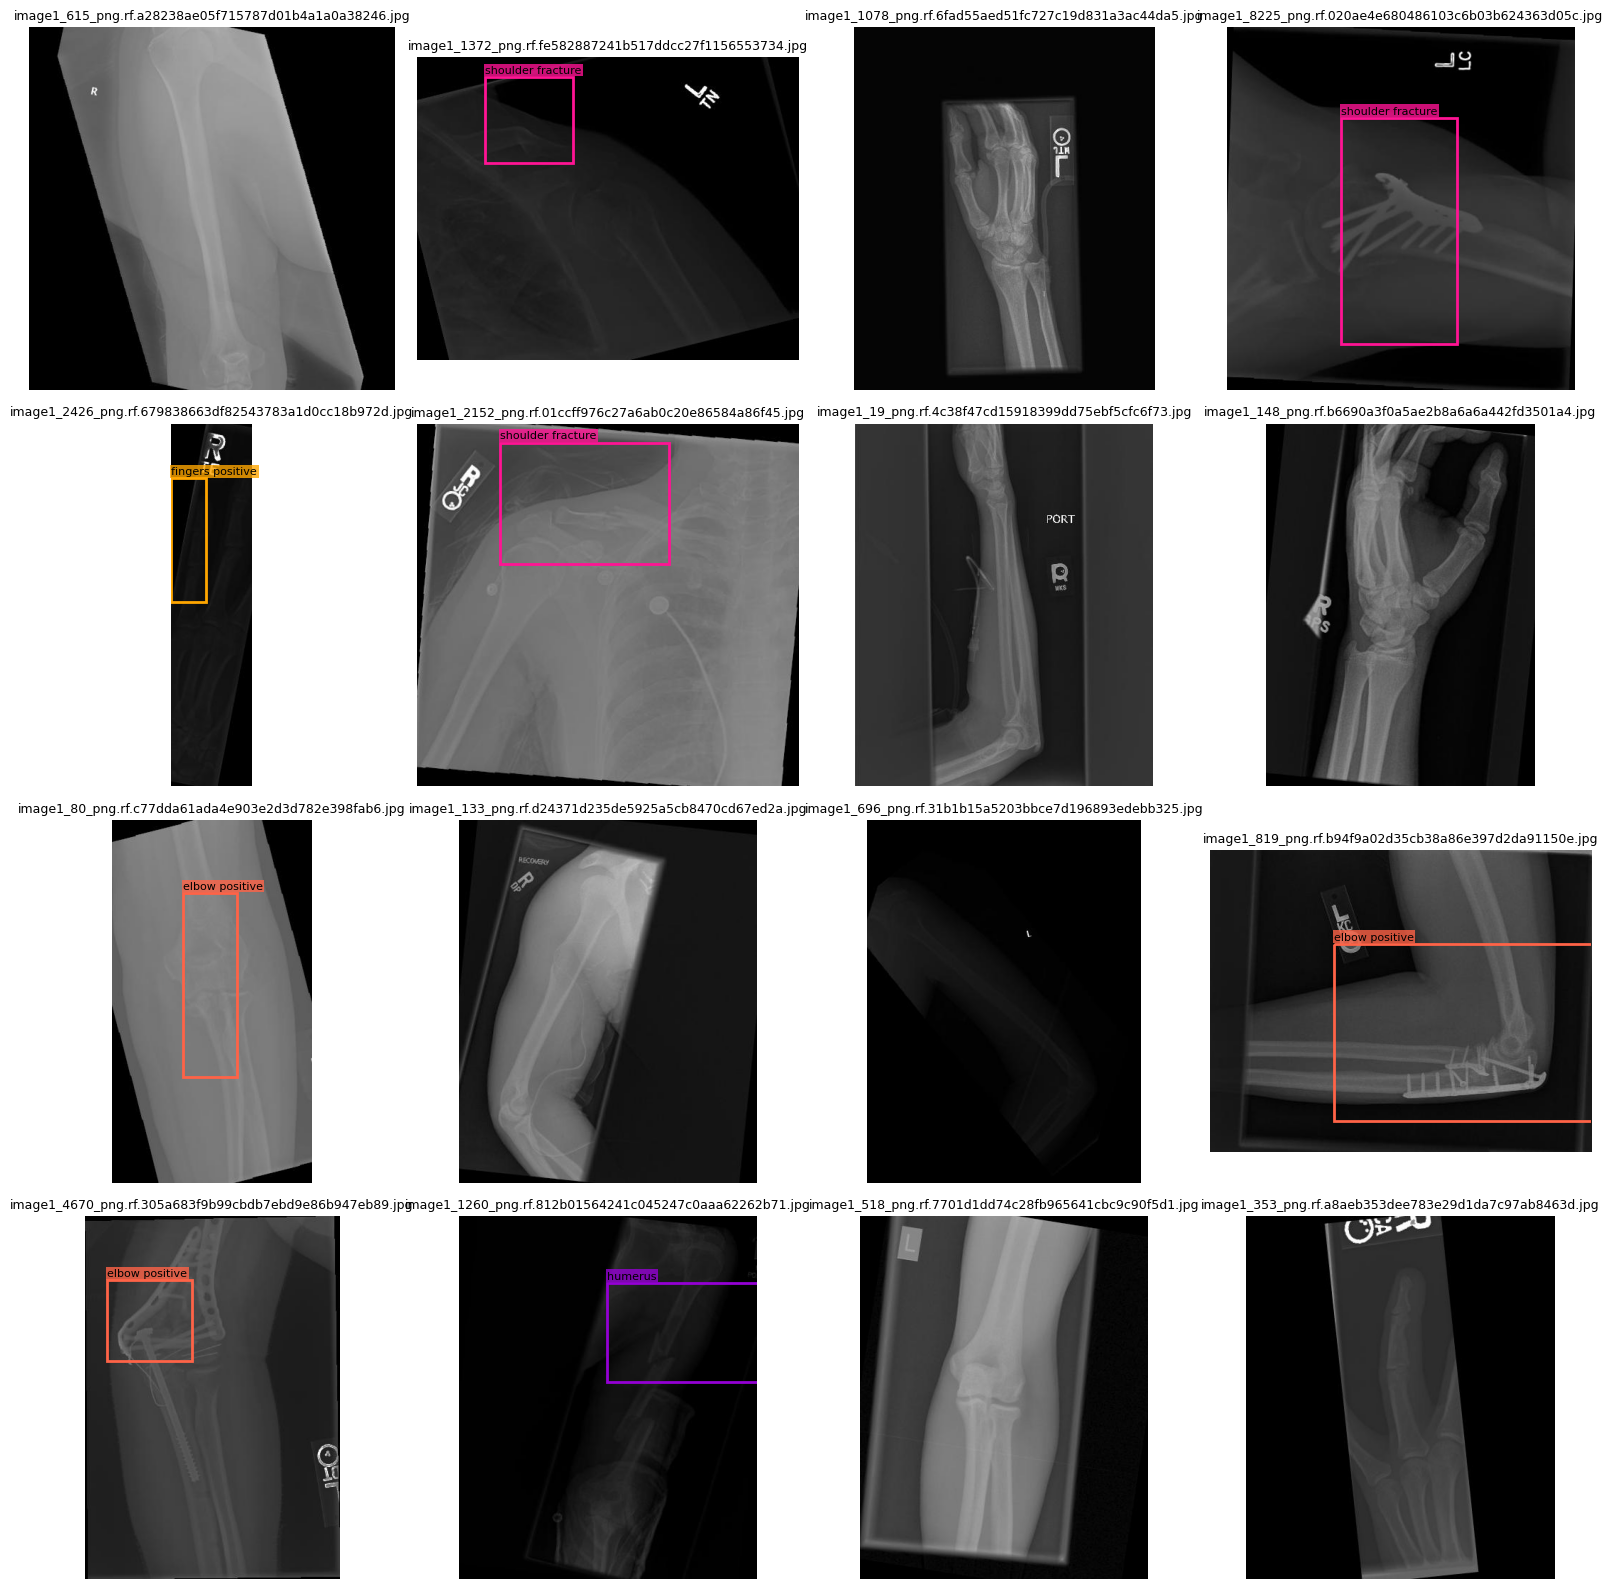

In [14]:
def plot_samples_with_boxes_merged(images_dir, labels_dir, n=16, seed=42):
    img_files = [f for f in os.listdir(images_dir)
                 if f.lower().endswith((".jpg", ".jpeg", ".png"))]

    random.seed(seed)
    sample_files = random.sample(img_files, k=min(n, len(img_files)))

    cols = 4
    rows = int(np.ceil(len(sample_files) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(16, 16))
    axes = axes.flatten()

    for i, ax in enumerate(axes):
        ax.axis("off")
        if i >= len(sample_files):
            continue

        img_name = sample_files[i]
        img_path = os.path.join(images_dir, img_name)

        img_bgr = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        H, W = img_rgb.shape[:2]

        label_name = os.path.splitext(img_name)[0] + ".txt"
        label_path = os.path.join(labels_dir, label_name)

        ax.imshow(img_rgb)
        ax.set_title(img_name, fontsize=9)

        if not os.path.exists(label_path) or os.path.getsize(label_path) == 0:
            continue

        with open(label_path, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                cls = int(float(parts[0]))
                xc, yc, w, h = map(float, parts[1:5])

                x1 = (xc - w/2) * W
                y1 = (yc - h/2) * H
                x2 = (xc + w/2) * W
                y2 = (yc + h/2) * H

                color = CLASS_COLORS_MERGED[cls]
                label = CLASS_NAMES_MERGED[cls]

                rect = mpatches.Rectangle((x1, y1), x2-x1, y2-y1,
                                          fill=False, linewidth=2, edgecolor=color)
                ax.add_patch(rect)

                ax.text(x1, max(0, y1 - 6), label, fontsize=8, color="black",
                        bbox=dict(facecolor=color, alpha=0.8, pad=1, edgecolor="none"))

    plt.tight_layout()
    plt.show()

plot_samples_with_boxes_merged(train_images, train_labels, n=16, seed=42)